In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    get_ipython().run_line_magic(
        'cd',
        '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-6'
    )
except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-6


In [ ]:
!pip install torchinfo

In [ ]:
import torch as tc
from tqdm import tqdm
import torch.nn as nn
from time import perf_counter
from torchinfo import summary
import matplotlib.pyplot as plt

bar = '-'*64
seed = 42
tc.manual_seed(seed)
device = 'cuda' if tc.cuda.is_available() else 'cpu'
print(f"using {device}")

using cpu


# <u>Using a Transformer with PyTorch</u>

With their capacity for parallelization and the ability to capture long-term dependencies in data, Transformers have immense potential in various fields, especially NLP tasks like translation, summarization, and sentiment analysis. In this notebook, we show how PyTorch's Transformer module `torch.nn.Transformer` can be used.

<img src="fig/transformer.png" width="500">
<img src="https://drive.google.com/uc?export=view&id=1V8iXJMkxSnWE8zs2H4AAudAVC2zlgVOj" width="500">

### <u>Embedding Layer</u>

Embeddings convert discrete tokens (which could be words, characters, or subwords) into dense vectors of fixed size. In the Transformer model, `nn.Embedding` layers are used to map each token in the source (`src_voc_size`) and target (`tgt_voc_size`) vocabularies to a vector space of dimension `d_model`.

Instead of representing tokens as integers, the embedding layer replaces each token ID with a continuous vector of length `d_model`. As a result, a sequence of token IDs with shape `[batch_size, seq_len]` becomes a tensor of shape `[batch_size, seq_len, d_model]`.

Internally, the embedding layer contains a matrix of trainable parameters of size `[V, d_model]`, where `V` is the vocabulary size. Each row of this matrix corresponds to the vector representation of one token.

The embedding operation can be interpreted as a lookup operation: given a token ID, the embedding layer simply returns the corresponding row from the embedding matrix. In other words, each token is replaced by its learned vector representation in the embedding space.

### <u>Positional Encoding Layer</u>

Unlike recurrent or convolutional models, the Transformer architecture does not process tokens sequentially. Instead, it relies entirely on the self-attention mechanism, which means that the model has **no inherent notion of token order**. To provide the model with information about the position of tokens in a sequence, we introduce **positional encodings**.

Positional encodings assign a unique vector to each position in the sequence. In the original Transformer architecture, these encodings are constructed using sinusoidal functions so that the model can more easily learn relationships between positions. The positional encoding is defined as:

\begin{equation}
\mathrm{PE}(\mathrm{pos}, i) =
\begin{cases}
\sin\left(f(\mathrm{pos}, 2i) \right) \\
\cos\left(f(\mathrm{pos}, 2i-1) \right)
\end{cases},
\tag{1}
\end{equation}

where:

\begin{equation}
f(\mathrm{pos}, i) = \mathrm{pos} \cdot \exp\left(-\frac{4 \cdot \ln(10) \cdot i}{d_\mathrm{model}}\right),
\tag{2}
\end{equation}

and $i = 0, 1, \dots, d_\mathrm{model}-1$, while $\mathrm{pos} = 0, 1, \dots, \mathrm{max\_seq\_len}-1$.

These sinusoidal functions produce smooth and unique encodings for each position in the sequence, allowing the model to infer both **absolute positions** and **relative distances** between tokens.

Once computed, the positional encoding matrix is **added** (not concatenated) to the embedding matrix $X$:

\begin{equation}
\mathrm{out}_{\mathrm{pos}, i} = x_{\mathrm{pos}, i} + \mathrm{pe}_{\mathrm{pos}, i}.
\tag{3}
\end{equation}

Adding the positional encodings introduces positional information without increasing the dimensionality of the representations. If concatenation were used instead, the dimensionality of the token representations would increase and the model would need to learn to separate positional and semantic information explicitly.

### Example:

To illustrate how embeddings and positional encodings work together, consider a very small example. Suppose the input sequence contains three tokens:

\begin{equation}
[3,\, 5,\, 1]
\tag{4}
\end{equation}

### Step 1: Embedding Lookup

Before entering the Transformer, these integer token IDs are converted into vectors via the embedding layer. Internally, the embedding layer contains a matrix of trainable parameters of size `[vocab_size, d_model]`. Each row of this embedding matrix represents the vector representation of a token in the vocabulary:

\begin{equation}
E^T =
\begin{bmatrix}
\cdots & e_3 & \cdots & e_5 & \cdots & e_1 & \cdots
\end{bmatrix},
\tag{5}
\end{equation}

where each vector $e_i$ is a learned representation of token $i$ of length $d_\mathrm{model}$.

When the sequence `[3, 5, 1]` is passed through the embedding layer, the model simply **selects the corresponding rows** of the embedding matrix. For example, if $d_\mathrm{model} = 4$:

\begin{equation}
X =
\begin{bmatrix}
e_3 \\
e_5 \\
e_1
\end{bmatrix}
=
\begin{bmatrix}
0.21 & -0.13 & 0.44 & 0.05 \\
0.37 & 0.09 & -0.28 & 0.61 \\
-0.12 & 0.47 & 0.18 & -0.33
\end{bmatrix}.
\tag{6}
\end{equation}

Thus the integer token sequence becomes a matrix of shape `[seq_len, d_model]`.

### Step 2: Positional Encoding

The embedding vectors contain semantic information about the tokens, but they do not contain any information about **where the tokens appear in the sequence**. To introduce positional information, the positional encoding layer generates vectors that depend only on the **position index**. For example, for position $\mathrm{pos} = 0$:

\begin{equation}
PE(0,0) = \sin(f(0,0)) = 0, \qquad
PE(0,1) = \cos(f(0,1)) = 1.
\tag{7}
\end{equation}

Using the sinusoidal equations introduced earlier, we obtain a positional encoding matrix such as:

\begin{equation}
PE =
\begin{bmatrix}
0.00 & 1.00 & 0.00 & 1.00 \\
0.84 & 0.54 & 0.01 & 1.00 \\
0.91 & -0.42 & 0.02 & 1.00
\end{bmatrix}.
\tag{8}
\end{equation}

Each row corresponds to the encoding of one position in the sequence.

### Step 3: Combining Both Representations

The final input to the Transformer is obtained by **adding** the positional encoding matrix to the embedding matrix:

\begin{equation}
X' = X + PE =
\begin{bmatrix}
0.21 & 0.87 & 0.44 & 1.05 \\
1.21 & 0.63 & -0.27 & 1.61 \\
0.79 & 0.05 & 0.20 & 0.67
\end{bmatrix}.
\tag{9}
\end{equation}

After this operation, each token representation contains both:

1) **semantic information** from the embedding layer  
2) **positional information** from the positional encoding

Even though the Transformer processes tokens in parallel, these positional signals allow the model to distinguish between tokens appearing in different positions of the sequence.

In [ ]:
loge4 = 4*tc.log(tc.tensor(10))

class PositionalEncoding(nn.Module):
    """Positional Encoding using sine and cosine functions of different
    frequencies to generate the positional encoding."""
    def __init__(self, d_model, max_seq_len):
        super(PositionalEncoding, self).__init__()
        # position = [0, 1, 2, ..., max_seq_len]:
        position = tc.arange(0, max_seq_len, dtype=tc.float).unsqueeze(1)
        # calculate for all i = [0, 2, 4, ..., d_model]:
        # exp((-4*ln(10)*i/d_model)):
        div_term = tc.exp(tc.arange(0, d_model, 2).float() * -(loge4 / d_model))
        # The positional encoding matrix is:
        pe = tc.zeros(max_seq_len, d_model)
        pe[:, 0::2] = tc.sin(position * div_term)
        pe[:, 1::2] = tc.cos(position * div_term)
        # self.register_buffer is used to register a tensor as a buffer in a Module.
        # Buffers are tensors that are not to be considered as model parameters;
        # i.e., they are not trainable and don't require gradients.
        # pe.unsqueeze(0) just adds a 0-th dimension (for the batch):
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

### <u>Masking</u>

As we explained in our tutorial document, masking in Transformers is crucial for controlling the flow of information, especially in the decoder. The reason is that, during training, the model should not be allowed to "see" future tokens when predicting the current one; otherwise, it would violate the autoregressive nature of the problem.

Let us consider a simple example. Suppose the target sequence is `["Hello", "world", "!"]`. During training, the decoder should predict each token using only the tokens that come before it. Therefore, the desired behavior is:

<pre>
Step   Input                              →   Target
----------------------------------------------------------
1      ["<bos>"]                               →   ["Hello"]
2      ["<bos>", "Hello"]                      →   ["world"]
3      ["<bos>", "Hello", "world"]             →   ["!"]
4      ["<bos>", "Hello", "world", "!"]        →   ["<eos>"]
</pre>

To enforce this behavior, we use a **target mask** `tgt_mask`. For a sequence of length 3, the mask has the following form:

\begin{equation}
\begin{bmatrix}
0 & -\infty & -\infty \\
0 & 0 & -\infty \\
0 & 0 & 0
\end{bmatrix}.
\tag{10}
\end{equation}

This upper-triangular mask ensures that each position in the decoder can attend only to previous positions and to itself, but not to future positions:

+ $0$ = attention to this position is **allowed**: $\mathrm{softmax}(0) = 1$
+ $-\infty$ = attention to this position is **blocked**: $\mathrm{softmax}(-\infty) = 0$

In code, such a mask could be created manually as: <br> `tgt_mask = tc.triu(tc.ones((3, 3)) * float('-inf'), diagonal=1)` <br> In practice, we do not need to construct it ourselves. PyTorch already provides the method: <br> `generate_square_subsequent_mask(...)` <br> which creates exactly this type of triangular mask. In our implementation, the mask is created with: <br> `generate_square_subsequent_mask(tgt.size(1))` <br> so that its size always matches the length of the target sequence.

This mask is then passed to the Transformer during the forward pass, preventing the decoder from "peeking" at future tokens:

In [ ]:
class TransformerModel(nn.Module):
    def __init__(
      self, src_voc_size, tgt_voc_size, d_model, num_heads,
      num_encoder_layers, num_decoder_layers, d_ff, max_seq_len, dropout
    ):
        super(TransformerModel, self).__init__()
        assert d_model % num_heads == 0, (
          "d_model must be divisible by num_heads"
        )
        # Using PyTorch's Transformer:
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )
        # Embedding layers for encoder and decoder:
        self.encoder_embedding = nn.Embedding(
            num_embeddings=src_voc_size, embedding_dim=d_model
        )
        self.decoder_embedding = nn.Embedding(
            num_embeddings=tgt_voc_size, embedding_dim=d_model
        )
        # Same positional encoding for encoder & decoder (no trainable parameters):
        self.positional_encoding = PositionalEncoding(d_model, max_seq_len)
        # Final linear layer:
        self.W_O = nn.Linear(d_model, tgt_voc_size)
        # Same dropout probability everywhere:
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, tgt):
        # Apply embedding, then PE, then dropout, to both source and target:
        src = self.dropout(
            self.positional_encoding(self.encoder_embedding(src))
        )
        tgt = self.dropout(
            self.positional_encoding(self.decoder_embedding(tgt))
        )
        # Generate mask for the decoder:
        tgt_mask = self.transformer.generate_square_subsequent_mask(
            sz=tgt.size(1),
            device=tgt.device
        )
        # Apply mask and pass through the Transformer (encoder & decoder):
        out = self.transformer(src=src, tgt=tgt, tgt_mask=tgt_mask)
        # Apply final transformation (with W_O) and return:
        return self.W_O(out)

## <u>Toy Dataset: Copy Task</u>

To demonstrate the sequence-to-sequence capabilities of the Transformer, we use a very simple synthetic task known as the **copy task**: The model receives a sequence of token IDs and must reproduce exactly the same sequence. Although this problem is trivial and artificial, it is useful for illustrating how the encoder–decoder architectures operate, and to verify that our implementation is (probably) correct.

Instead of loading data from a corpus, we generate sequences of random integers representing token IDs. These tokens come from a small-sized vocabulary where three tokens are reserved as special symbols:

$0$ = `<pad>` $=$ padding token  
$1$ = `<bos>` $=$ beginning-of-sequence token  
$2$ = `<eos>` $=$ end-of-sequence token  

All remaining integers represent regular tokens.

The Transformer should produce exactly the same sequence as output. Remember that during training, the decoder does not see the full target sequence. Instead it receives a shifted version of the sequence (beginning with the `<bos>` token).

Model hyperparameters:

In [ ]:
# Special tokens:
pad_id = 0
bos_id = 1
eos_id = 2

# Small vocabulary for toy task:
src_vocab_size = 30
tgt_vocab_size = 30

# Small model:
dmodel = 32
max_seq_length = 12
seq_len = 8
nheads = 4
nlayers = 1
dff = 64
drop = 0.0 # larger for harder tasks

Initialization:

In [ ]:
# Initialize the model:
transformer = TransformerModel(
    src_voc_size=src_vocab_size,
    tgt_voc_size=tgt_vocab_size,
    d_model=dmodel,
    num_heads=nheads,
    num_encoder_layers=nlayers,
    num_decoder_layers=nlayers,
    d_ff=dff,
    max_seq_len=max_seq_length,
    dropout=drop
).to(device)

# create dummy inputs to view summary:
src = tc.randint(0, src_vocab_size, (1, max_seq_length)).to(device)
tgt = tc.randint(0, tgt_vocab_size, (1, max_seq_length)).to(device)
print(summary(
    transformer,
    input_data=(src, tgt),
    depth=3,
    col_names=("input_size", "output_size", "num_params"),
))

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #
TransformerModel                                   [1, 12]                   [1, 12, 30]               --
├─Embedding: 1-1                                   [1, 12]                   [1, 12, 32]               960
├─PositionalEncoding: 1-2                          [1, 12, 32]               [1, 12, 32]               --
├─Dropout: 1-3                                     [1, 12, 32]               [1, 12, 32]               --
├─Embedding: 1-4                                   [1, 12]                   [1, 12, 32]               960
├─PositionalEncoding: 1-5                          [1, 12, 32]               [1, 12, 32]               --
├─Dropout: 1-6                                     [1, 12, 32]               [1, 12, 32]               --
├─Transformer: 1-7                                 --                        [1, 12, 32]               --
│    └─TransformerEncoder: 2-1         

In [ ]:
# Training hyperparameters:
lr_ = 1e-3
betas_ = (0.9, 0.98)
eps_ = 1e-9
num_iters = 300
batch_size = 64

pad_id = 0
bos_id = 1
eos_id = 2

loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = tc.optim.Adam(
    params=transformer.parameters(),
    lr=lr_,
    betas=betas_,
    eps=eps_
)

def make_copy_batch(batch_size, seq_len, vocab_size, device):
    # tokens 0,1,2 are reserved for PAD, BOS, EOS
    src_core = tc.randint(3, vocab_size, (batch_size, seq_len), device=device)

    src = src_core
    tgt_in = tc.cat([
        tc.full((batch_size, 1), bos_id, device=device),
        src_core
    ], dim=1)

    tgt_out = tc.cat([
        src_core,
        tc.full((batch_size, 1), eos_id, device=device)
    ], dim=1)

    return src, tgt_in, tgt_out

## <u>Training our PyTorch Transformer Model</u>

What follows now is our training loop. We have established that the model predicts the next token given the previous ones, so we have to:
+ (1) Exclude the last token from the target ("shifted right" part) when calling the model, because essentially nothing follows afterwards for the model to predict.
+ (2) Exclude the first token when computing the loss because the first token the model tries to predict is not the start-of-sequence token, but the first actual token of the sequence.

In [ ]:
loss_history = []
tok_acc_history = []

tic = perf_counter()
transformer.train()
pbar = tqdm(range(num_iters), desc='Iterations')
print_every = 20

for epoch in pbar:
    src_data, tgt_in_data, tgt_out_data = make_copy_batch(
        batch_size=batch_size,
        seq_len=seq_len,
        vocab_size=src_vocab_size,
        device=device
    )

    optimizer.zero_grad()

    output = transformer(src_data, tgt_in_data)
    output_aligned = output.contiguous().view(-1, tgt_vocab_size)
    target_aligned = tgt_out_data.contiguous().view(-1)

    loss = loss_fn(output_aligned, target_aligned)

    pred_tokens = output.argmax(dim=-1)
    tok_acc = (pred_tokens == tgt_out_data).float().mean() * 100

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    tok_acc_history.append(tok_acc.item())

    if (epoch + 1) % print_every == 0:
        tqdm.write(
            f"\nIteration {epoch+1:3d}/{num_iters:3d} | "
            f"Loss: {loss.item():.4f} | "
            f"TokAcc: {tok_acc.item():6.2f}%"
        )

toc = perf_counter()
print(f"Time elapsed: {toc-tic:.4f} seconds.")

Iterations:  10%|█         | 30/300 [00:00<00:03, 69.09it/s]


Iteration  20/300 | Loss: 3.2687 | TokAcc:  11.98%


Iterations:  17%|█▋        | 52/300 [00:00<00:03, 69.14it/s]


Iteration  40/300 | Loss: 3.1178 | TokAcc:  14.58%


Iterations:  22%|██▏       | 66/300 [00:00<00:03, 63.78it/s]

...


Iteration 260/300 | Loss: 0.3259 | TokAcc:  95.66%


Iterations:  94%|█████████▍| 283/300 [00:07<00:00, 22.36it/s]


Iteration 280/300 | Loss: 0.2327 | TokAcc:  97.05%


Iterations: 100%|██████████| 300/300 [00:08<00:00, 37.12it/s]


Iteration 300/300 | Loss: 0.1374 | TokAcc:  99.13%
Time elapsed: 8.0916 seconds.


Plotting:

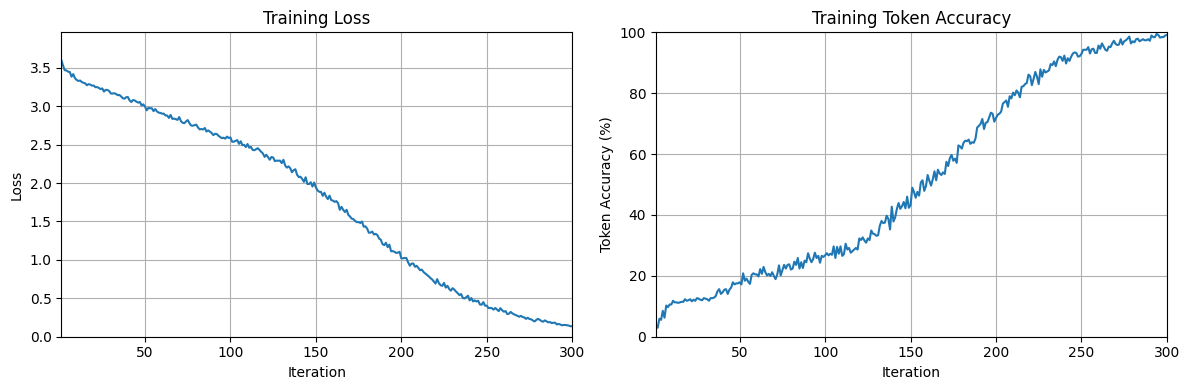

In [ ]:
iters = range(1, num_iters + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax[0].plot(iters, loss_history)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training Loss")
ax[0].set_xlim(1, num_iters)
ax[0].set_ylim(0, max(loss_history)*1.1)
ax[0].grid(True)

# Accuracy plot
ax[1].plot(iters, tok_acc_history)
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Token Accuracy (%)")
ax[1].set_title("Training Token Accuracy")
ax[1].set_xlim(1, num_iters)
ax[1].set_ylim(0, 100)
ax[1].grid(True)

plt.tight_layout()
plt.show()
plt.close()

Validation:

In [ ]:
transformer.eval()
with tc.no_grad():
    src_data, tgt_in_data, tgt_out_data = make_copy_batch(
        batch_size=256,
        seq_len=seq_len,
        vocab_size=src_vocab_size,
        device=device
    )

    output = transformer(src_data, tgt_in_data)
    pred_tokens = output.argmax(dim=-1)

    tok_acc = (pred_tokens == tgt_out_data).float().mean()

print(f"Validation token accuracy: {100*tok_acc.item():.2f}%")

Validation token accuracy: 98.87%


## <u>Optional Homework</u>

1. **Model Size**  
   Change the model dimension and number of parameters in general and observe how this affects the training behavior of the model.

2. **Vocabulary Size**  
   Increase/Decrease the vocabulary size used in the toy dataset and note what happens to the model.

3. **Sequence Reversal Task**  
   Modify the dataset so that the model must output the **reversed sequence** instead of copying it.  
   Example: input `[3, 5, 1]` → output `[1, 5, 3]`.  
   Try to train the Transformer on this task.

## <u>References</u>

+ Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017).  
  *Attention Is All You Need.*  
  Advances in Neural Information Processing Systems (NeurIPS).  
  https://arxiv.org/abs/1706.03762

+ PyTorch Documentation – Transformer module:  
  https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html

+ PyTorch Documentation – Multihead Attention:  
  https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html

+ PyTorch Tutorials – Sequence-to-Sequence modeling with attention:  
  https://pytorch.org/tutorials/

+ The Annotated Transformer (Harvard NLP):  
  https://nlp.seas.harvard.edu/annotated-transformer/

+ Dive into Deep Learning – Attention and Transformers:  
  https://d2l.ai/chapter_attention-mechanisms/